<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


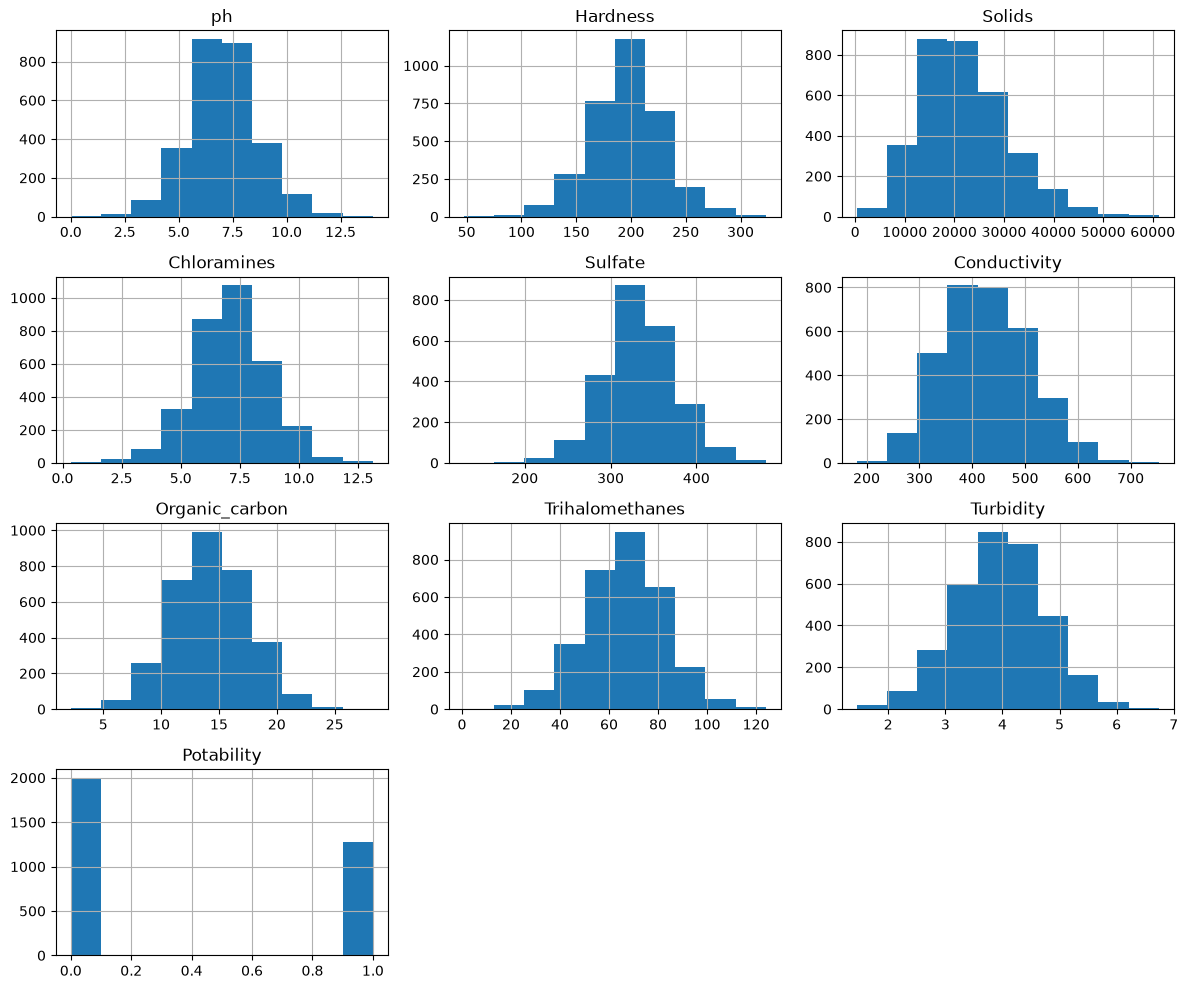

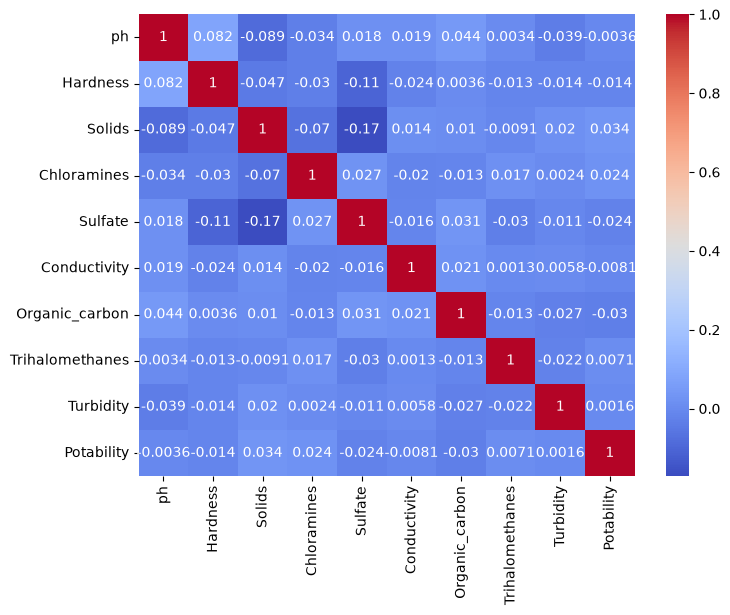

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/Likith K M/Downloads/archive/water_potability.csv")
df.head()
df.info()
df.describe()

# missing values
df.isnull().sum()

# class balance
df['Potability'].value_counts(normalize=True)

# distributions
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [2]:
# Fill missing values with median (simple, defensible choice)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Drop duplicates if any
df = df.drop_duplicates()

X = df.drop("Potability", axis=1)
y = df["Potability"]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Model 1
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression")
print(classification_report(y_test, pred_lr))

# Model 2
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)  # trees don't need scaling
pred_dt = dt.predict(X_test)
print("Decision Tree")
print(classification_report(y_test, pred_dt))

Logistic Regression
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656

Decision Tree
              precision    recall  f1-score   support

           0       0.65      0.89      0.75       400
           1       0.59      0.26      0.36       256

    accuracy                           0.64       656
   macro avg       0.62      0.57      0.56       656
weighted avg       0.63      0.64      0.60       656



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [4]:
print(classification_report(y_test, pred_lr, zero_division=0))

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656



In [5]:
print(confusion_matrix(y_test, pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

[[355  45]
 [190  66]]
ROC-AUC: 0.608330078125


In [6]:
import joblib
joblib.dump(dt, "model.pkl")           # or lr, whichever performed better
joblib.dump(scaler, "scaler.pkl")      # only needed if using LR

['scaler.pkl']

In [7]:
import streamlit as st
import joblib
import numpy as np
import pandas as pd

model = joblib.load("model.pkl")

st.title("💧 Water Quality Risk Classifier")
st.write("Enter water sample measurements to predict potability risk.")

ph = st.number_input("pH", 0.0, 14.0, 7.0)
hardness = st.number_input("Hardness", 0.0, 500.0, 150.0)
solids = st.number_input("Solids (Turbidity proxy)", 0.0, 60000.0, 20000.0)
chloramines = st.number_input("Chloramines", 0.0, 15.0, 5.0)
sulfate = st.number_input("Sulfate", 0.0, 500.0, 250.0)
conductivity = st.number_input("Conductivity", 0.0, 1000.0, 400.0)
organic_carbon = st.number_input("Organic Carbon", 0.0, 30.0, 10.0)
trihalomethanes = st.number_input("Trihalomethanes", 0.0, 130.0, 60.0)
turbidity = st.number_input("Turbidity", 0.0, 10.0, 4.0)

if st.button("Predict"):
    input_data = np.array([[ph, hardness, solids, chloramines, sulfate,
                             conductivity, organic_carbon, trihalomethanes, turbidity]])
    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1]

    if pred == 1:
        st.success(f"✅ Likely Potable — confidence {prob:.2%}")
    else:
        st.error(f"⚠️ Likely Not Potable — confidence {(1-prob):.2%}")

2026-09-27 12:34:46.255 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 12:34:47.272 
  command:

    streamlit run C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-27 12:34:47.273 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 12:34:47.274 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 12:34:47.276 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 12:34:47.279 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 12:34:47.280 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 12:34:47.281 Thread 'MainThread': mi

In [8]:
import joblib
joblib.dump(dt, r"C:\Users\Likith K M\Downloads\archive\model.pkl")

['C:\\Users\\Likith K M\\Downloads\\archive\\model.pkl']

In [9]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [10]:
df['Potability'].value_counts(normalize=True)

Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64

In [11]:
from sklearn.metrics import confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

[[355  45]
 [190  66]]
ROC-AUC: 0.608330078125
